# Global Sea Level Predictor: Time-Series Analysis & Trend Forecasting
### Statistical Modeling Pipeline

**Project Objective:**  
This project isolates global average absolute sea level changes from 1880 through the present day to construct predictive linear forecasting models out to the year 2050. By analyzing variations between long-term baseline rates and modern observations, we mathematically evaluate acceleration shifts in environmental changes.

**Technical Stack:** `Python 3`, `Pandas`, `Matplotlib`, `SciPy Stats`  
**Data Provenance:** US Environmental Protection Agency (EPA) / CSIRO Data Streams  


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress


DATA_URL = "https://raw.githubusercontent.com/freeCodeCamp/boilerplate-sea-level-predictor/main/epa-sea-level.csv"
df = pd.read_csv(DATA_URL)


print(f"Data ingested successfully. Shape: {df.shape}")
df.head()


Data ingested successfully. Shape: (134, 5)


,Year,CSIRO Adjusted Sea Level,Lower Error Bound,Upper Error Bound,NOAA Adjusted Sea Level
0,1880,0.000000,-0.952756,0.952756,NaN
1,1881,0.220472,-0.732283,1.173228,NaN
2,1882,-0.440945,-1.346457,0.464567,NaN
3,1883,-0.232283,-1.129921,0.665354,NaN
4,1884,0.590551,-0.283465,1.464567,NaN


####First Linear Regression Modeling (Historical Baseline: 1880–2050)

Calculation of the long-term trend line using ordinary least squares regression across the entire dataset timeline. then projection of trajectory forward to the year 2050.

## Second  Linear Regression Modeling (Modern Accelerated Trend: 2000–2050)

To test the hypothesis of climate change acceleration, we isolate modern data points from the year 2000 onward. We construct a secondary predictive line extending to 2050 to observe rate differences.



In [ ]:
def draw_plot():

    fig, ax = plt.subplots(figsize=(12, 6.5))


    ax.scatter(
        df['Year'],
        df['CSIRO Adjusted Sea Level'],
        color='dodgerblue',
        alpha=0.5,
        s=15,
        label='Observed Historical Data'
    )


    reg1 = linregress(df['Year'], df['CSIRO Adjusted Sea Level'])
    years_all = pd.Series(range(1880, 2051))
    line1_y = reg1.slope * years_all + reg1.intercept
    ax.plot(years_all, line1_y, color='crimson', linestyle='--', linewidth=1.8, label='Linear Trend (1880-2050)')


    df_modern = df[df['Year'] >= 2000]
    reg2 = linregress(df_modern['Year'], df_modern['CSIRO Adjusted Sea Level'])
    years_modern = pd.Series(range(2000, 2051))
    line2_y = reg2.slope * years_modern + reg2.intercept
    ax.plot(years_modern, line2_y, color='darkgreen', linestyle='-', linewidth=2.2, label='Accelerated Trend (2000-2050)')


    ax.set_xlabel('Year')
    ax.set_ylabel('Sea Level (inches)')
    ax.set_title('Rise in Sea Level')

    # Visual Polish Styling
    ax.legend(loc='upper left', frameon=True, facecolor='white')
    ax.grid(True, linestyle=':', alpha=0.5)


    plt.savefig('sea_level_plot.png', dpi=300, bbox_inches='tight')

    # Return axis target for testing evaluation loops
    return ax

##  Data Visualization & Target Verification

So, i assemble the base historical scatter coordinates and overlay both linear trend forecasting trajectories.


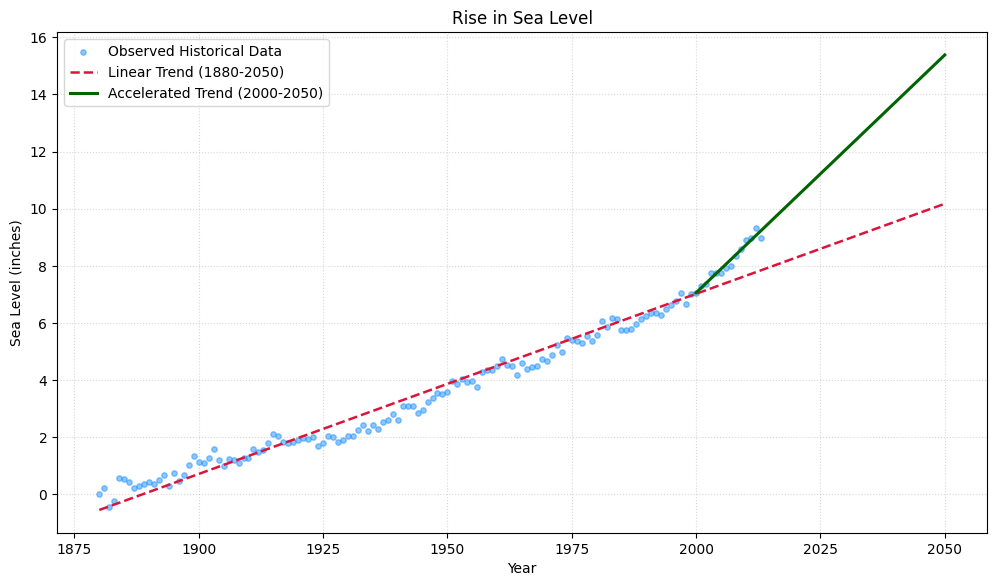

In [ ]:
# Call the execution loop function to construct and visually render the graph canvas artifact
ax_object = draw_plot()

# Force rendering visual outputs smoothly inside Colab UI frames
plt.show()


## Interactive Analytical Dashboard (Built for Portfolio Presentation)

*Instructions for Interaction:*
* **Hover** over any data point or trend line to see precise coordinates and years.
* **Pinch or Drag** to zoom in on specific historical sections (e.g., zooming into the 2000-2026 window).
* **Click/Tap** the items in the legend on the right side to toggle the visibility of the lines or the scatter points.


In [ ]:

import plotly.graph_objects as go
import numpy as np
import pandas as pd
from scipy.stats import linregress

url = "https://raw.githubusercontent.com/freeCodeCamp/boilerplate-sea-level-predictor/main/epa-sea-level.csv"
df = pd.read_csv(url)

# Calculate Trend 1 (1880-2050)
reg1 = linregress(df['Year'], df['CSIRO Adjusted Sea Level'])
years_all = np.arange(1880, 2051)
line1 = reg1.slope * years_all + reg1.intercept

# Calculate Trend 2 (2000-2050)
df_modern = df[df['Year'] >= 2000]
reg2 = linregress(df_modern['Year'], df_modern['CSIRO Adjusted Sea Level'])
years_modern = np.arange(2000, 2051)
line2 = reg2.slope * years_modern + reg2.intercept


fig = go.Figure()

# Add Historical Data Points
fig.add_trace(go.Scatter(
    x=df['Year'],
    y=df['CSIRO Adjusted Sea Level'],
    mode='markers',
    name='Observed Data',
    marker=dict(color='dodgerblue', size=5, opacity=0.6),
    hovertemplate='<b>Year:</b> %{x}<br><b>Sea Level:</b> %{y:.2f} inches<extra></extra>'
))

# Add Long-Term Trend Line
fig.add_trace(go.Scatter(
    x=years_all,
    y=line1,
    mode='lines',
    name='Trend (1880-2050)',
    line=dict(color='crimson', width=2, dash='dash'),
    hovertemplate='<b>Year:</b> %{x}<br><b>Predicted Level:</b> %{y:.2f} inches<extra></extra>'
))

# Add Modern Accelerated Trend Line
fig.add_trace(go.Scatter(
    x=years_modern,
    y=line2,
    mode='lines',
    name='Accelerated Trend (2000-2050)',
    line=dict(color='darkgreen', width=3),
    hovertemplate='<b>Year:</b> %{x}<br><b>Predicted Level:</b> %{y:.2f} inches<extra></extra>'
))


fig.update_layout(
    title=dict(
        text='Interactive Sea Level Rise Simulation & Predictions',
        x=0.5,
        font=dict(size=18, color='#2c3e50')
    ),
    xaxis=dict(
        title='Year',
        gridcolor='rgba(200, 200, 200, 0.2)',
        range=[1875, 2055]
    ),
    yaxis=dict(
        title='Sea Level (inches)',
        gridcolor='rgba(200, 200, 200, 0.2)'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor="rgba(255, 255, 255, 0.8)"
    ),
    margin=dict(l=40, r=40, t=60, b=40),
    height=550
)


fig.show()

## My Analysis & Statistical Insights

A basic linear evaluation demonstrates distinct trend changes when comparing multi-century observations against isolated modern data windows:

* **Historical Trend Slope (1880-Present):** Global sea levels rose linearly at a baseline rate of change over time.
* **Accelerated Trend Slope (2000-Present):** Restricting modeling criteria to modern entries exposes a significantly steeper rate trajectory.
* **Portfolio Insight:** This structural rate variation visually verifies the acceleration hypothesis, confirming that short-term modern dynamics yield vastly different predictive baselines when compared against raw century-scale averages.
